imports

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path

configuration

In [2]:
INPUT_FILE  = Path("../../data/raw/icsa_affiliations.json")
OUTPUT_DIR  = Path("figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

Load & deduplicate

In [3]:
with open(INPUT_FILE) as f:
    raw = json.load(f)
 
df = (
    pd.DataFrame(raw)
    .dropna(subset=["country_code"])
    .drop_duplicates(subset=["doi", "year", "country_code"])
    .copy()
)
 
print(f"Loaded {len(df):,} deduplicated rows across {df.year.nunique()} years")

Loaded 626 deduplicated rows across 16 years


region mapping

In [4]:
REGION_MAP = {
    "AU": "Asia-Pacific", "NZ": "Asia-Pacific", "CN": "Asia-Pacific",
    "IN": "Asia-Pacific", "TH": "Asia-Pacific", "SG": "Asia-Pacific",
    "JP": "Asia-Pacific", "KR": "Asia-Pacific",
    "US": "North America", "CA": "North America", "MX": "North America",
    "DE": "Europe", "FR": "Europe", "GB": "Europe", "IT": "Europe",
    "ES": "Europe", "NL": "Europe", "SE": "Europe", "FI": "Europe",
    "DK": "Europe", "NO": "Europe", "AT": "Europe", "BE": "Europe",
    "CH": "Europe", "PL": "Europe", "PT": "Europe", "CZ": "Europe",
    "IE": "Europe", "HU": "Europe", "RO": "Europe", "SI": "Europe",
    "IS": "Europe", "LU": "Europe", "HR": "Europe", "TR": "Europe",
    "GR": "Europe",
    "BR": "Latin America", "AR": "Latin America", "CL": "Latin America",
    "CO": "Latin America", "MX": "Latin America",
    "TN": "Africa & Middle East", "DZ": "Africa & Middle East",
    "JO": "Africa & Middle East", "ZA": "Africa & Middle East",
    "EG": "Africa & Middle East",
}
 
REGION_ORDER = [
    "Europe",
    "North America",
    "Asia-Pacific",
    "Latin America",
    "Africa & Middle East",
    "Unknown",
]
 
REGION_COLORS = {
    "Europe":               "#3266ad",
    "North America":        "#e07b3a",
    "Asia-Pacific":         "#3aa66b",
    "Latin America":        "#b04db0",
    "Africa & Middle East": "#c0474a",
    "Unknown":              "#888780",
}
 
df["region"] = df["country_code"].map(REGION_MAP).fillna("Unknown")
 
# ── Build per-year region percentages ─────────────────────────────────────────
 
region_year = (
    df.groupby(["year", "region"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=REGION_ORDER, fill_value=0)
)
region_pct = region_year.div(region_year.sum(axis=1), axis=0) * 100
years = region_pct.index.tolist()

plot 1: line chart--regional share over time

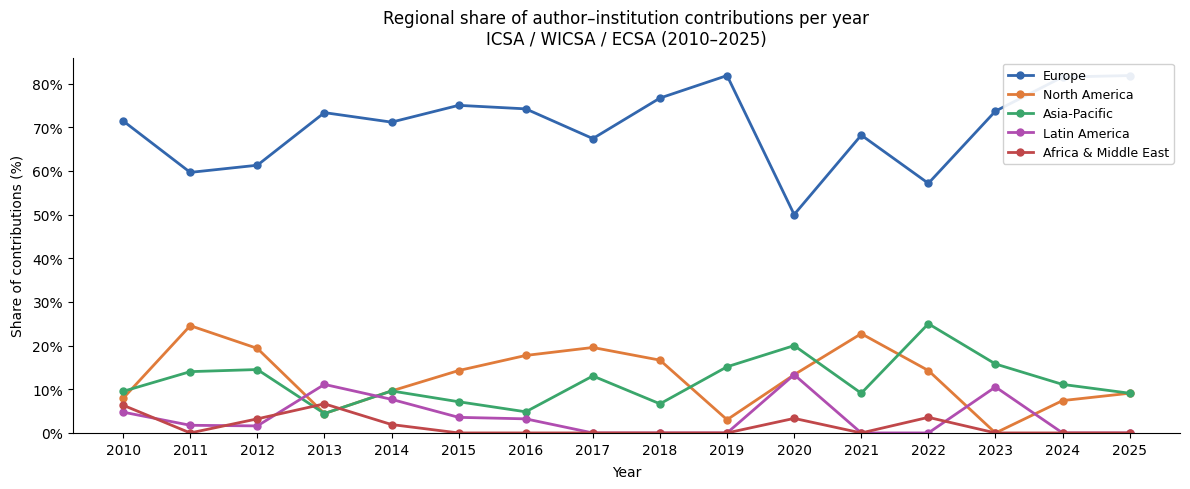

Saved → figures/fig_region_line.png


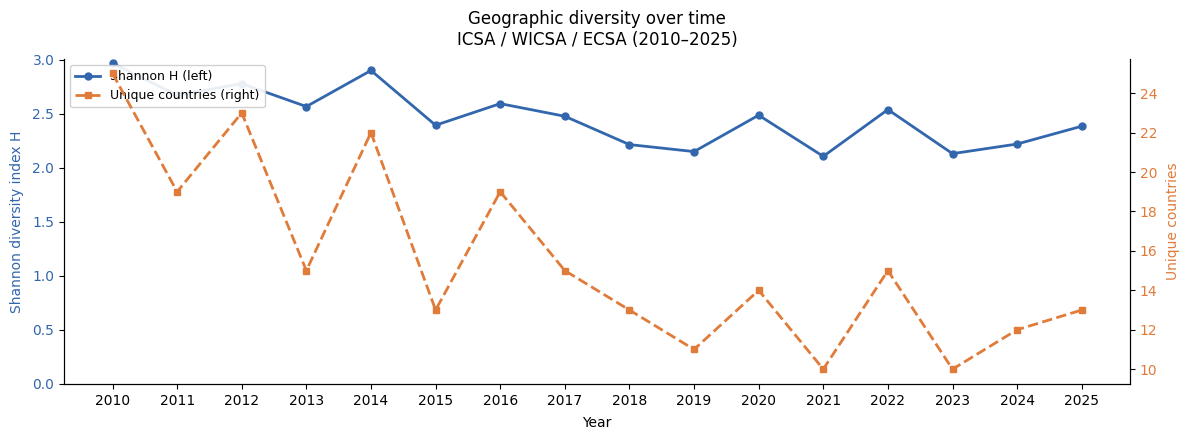

Saved → figures/fig_diversity.png


In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
 
for region in REGION_ORDER:
    if region not in region_pct.columns:
        continue
    vals = region_pct[region]
    if vals.max() < 1:
        continue  # skip regions with negligible presence
    ax.plot(
        years, vals,
        "o-",
        color=REGION_COLORS[region],
        linewidth=2,
        markersize=5,
        label=region,
    )
 
ax.set_xlabel("Year", labelpad=6)
ax.set_ylabel("Share of contributions (%)", labelpad=6)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xticks(years)
ax.set_ylim(bottom=0)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper right", fontsize=9, framealpha=0.9)
ax.set_title(
    "Regional share of author–institution contributions per year\n"
    "ICSA / WICSA / ECSA (2010–2025)",
    pad=10,
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_region_line.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/fig_region_line.png")

 
# ── Plot 3: Shannon diversity index over time ──────────────────────────────────
 
def shannon(counts):
    s = pd.Series(counts)
    s = s[s > 0]
    p = s / s.sum()
    return float(-(p * np.log(p)).sum())
 
diversity = []
for year, g in df.groupby("year"):
    cc_counts = g["country_code"].value_counts()
    diversity.append({
        "year":        year,
        "shannon_H":   round(shannon(cc_counts), 3),
        "n_countries": g["country_code"].nunique(),
        "n_papers":    g["doi"].nunique(),
    })
 
div_df = pd.DataFrame(diversity).set_index("year")
 
fig, ax1 = plt.subplots(figsize=(12, 4.5))
ax2 = ax1.twinx()
 
l1, = ax1.plot(div_df.index, div_df["shannon_H"], "o-",
               color="#3266ad", lw=2, ms=5, label="Shannon H (left)")
l2, = ax2.plot(div_df.index, div_df["n_countries"], "s--",
               color="#e07b3a", lw=2, ms=5, label="Unique countries (right)")
 
ax1.set_xlabel("Year", labelpad=6)
ax1.set_ylabel("Shannon diversity index H", color="#3266ad", labelpad=6)
ax2.set_ylabel("Unique countries", color="#e07b3a", labelpad=6)
ax1.tick_params(axis="y", labelcolor="#3266ad")
ax2.tick_params(axis="y", labelcolor="#e07b3a")
ax1.set_xticks(div_df.index)
ax1.set_ylim(bottom=0)
ax1.spines[["top"]].set_visible(False)
ax2.spines[["top"]].set_visible(False)
 
lines = [l1, l2]
ax1.legend(lines, [l.get_label() for l in lines],
           loc="upper left", fontsize=9, framealpha=0.9)
ax1.set_title("Geographic diversity over time\nICSA / WICSA / ECSA (2010–2025)", pad=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_diversity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/fig_diversity.png")